# Prédiction du risque d’abandon scolaire par Machine Learning

## Introduction

L’abandon scolaire constitue un enjeu majeur pour les systèmes éducatifs, car il impacte directement la réussite académique des étudiants ainsi que leur insertion professionnelle future. Identifier précocement les étudiants à risque permet de mettre en place des actions préventives adaptées et d’améliorer les taux de réussite.

Dans ce mini-projet, nous cherchons à développer un modèle de Machine Learning capable de prédire le risque d’abandon scolaire à partir de données académiques et comportementales. Chaque observation représente un étudiant caractérisé par des variables telles que l’âge, le sexe, la moyenne générale, le taux d’absentéisme ou encore le temps d’étude.

Le problème est formulé comme une tâche de classification binaire, où l’objectif est de prédire si un étudiant est à risque d’abandon (1) ou non (0). 

Ce projet suivra les étapes classiques d’un pipeline de Data Science, incluant l’exploration des données, le prétraitement, la modélisation et l’évaluation des performances des modèles.


## IMPORTATION DES LIBRAIRIES

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

## CHARGEMENT DES DONNEES 

In [6]:
# Lire le fichier CSV ET Afficher les premières lignes
df = pd.read_csv("student_dropout_dataset.csv")
print(df.head())

   age  gender  average_grade  absenteeism_rate internet_access  \
0   21    Male          16.27              0.35             Yes   
1   18  Female          12.30              0.38              No   
2   22    Male           8.10              0.04              No   
3   19    Male          13.84              0.25              No   
4   21  Female          14.62              0.47             Yes   

   study_time_hours extra_activities  dropout_risk  
0               4.1               No             0  
1               0.2               No             1  
2               3.4               No             0  
3               4.8              Yes             0  
4               0.6              Yes             1  


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               300 non-null    int64  
 1   gender            300 non-null    object 
 2   average_grade     300 non-null    float64
 3   absenteeism_rate  300 non-null    float64
 4   internet_access   300 non-null    object 
 5   study_time_hours  300 non-null    float64
 6   extra_activities  300 non-null    object 
 7   dropout_risk      300 non-null    int64  
dtypes: float64(3), int64(2), object(3)
memory usage: 18.9+ KB


  ## Prétraitement des données (Data Cleaning) 

L’objectif de cette étape est de comprendre la structure et la qualité des données avant la modélisation. Nous allons :

- Examiner la structure générale du dataset
- Identifier et traiter les valeurs manquantes
- Analyser les statistiques descriptives
- Transformer les variables catégorielles (encodage)
- Mettre à l’échelle les variables numériques (normalisation)

In [8]:
df.isnull().sum()

age                 0
gender              0
average_grade       0
absenteeism_rate    0
internet_access     0
study_time_hours    0
extra_activities    0
dropout_risk        0
dtype: int64

In [9]:
df_encoded = pd.get_dummies(df)

In [10]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_encoded)

# Reconvertir en DataFrame
df_scaled = pd.DataFrame(df_scaled, columns=df_encoded.columns)

In [11]:
 # Séparer features et target
X = df_encoded.drop("dropout_risk", axis=1)
y = df_encoded["dropout_risk"]

In [12]:
# Normalisation (Z-score)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

 ## Analyse exploratoire des données (EDA)

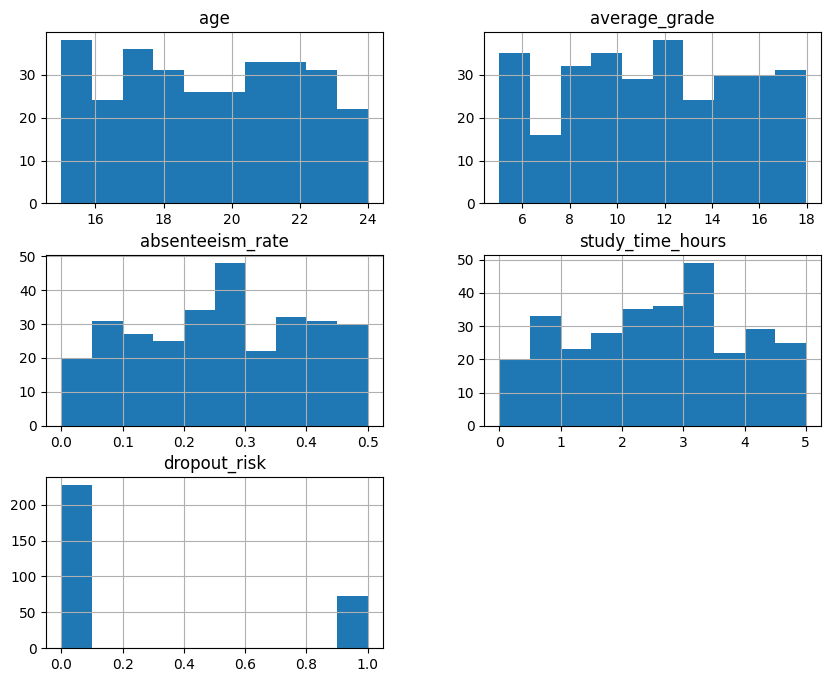

In [13]:
df.hist(figsize=(10,8))
plt.show()

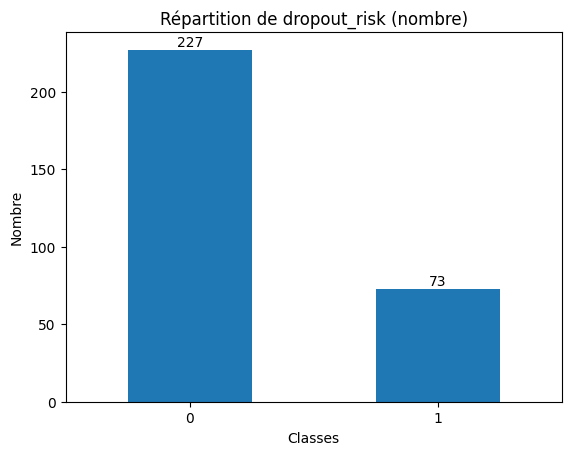

In [44]:
ax = data.plot(kind="bar")

for i, v in enumerate(data):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.title("Répartition de dropout_risk (nombre)")
plt.xlabel("Classes")
plt.ylabel("Nombre")
plt.xticks(rotation=0)

plt.show()

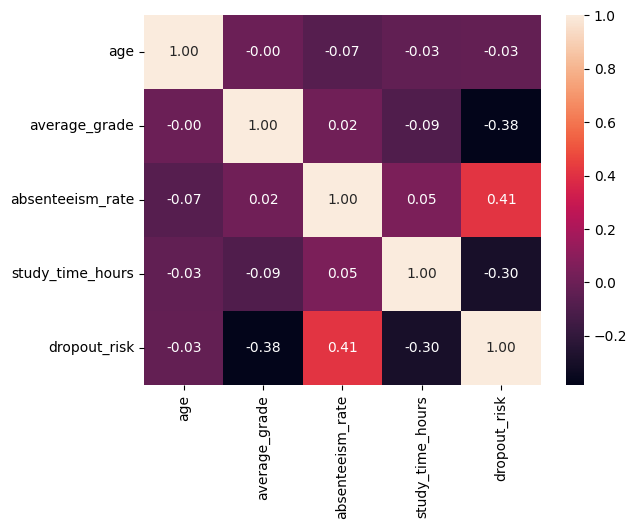

In [15]:

corr = df.corr(numeric_only=True)
plt.figure()
sns.heatmap(corr, annot=True, fmt=".2f")
plt.show()

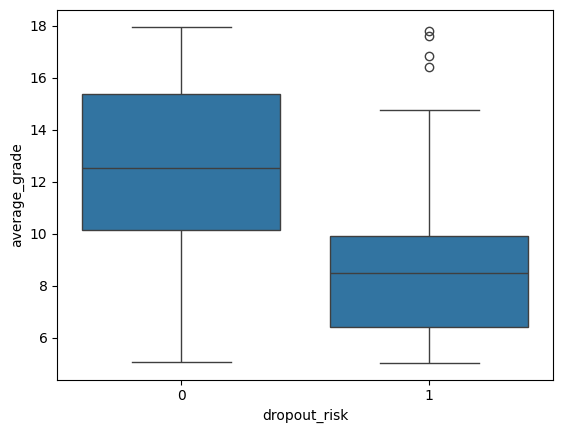

In [16]:
sns.boxplot(x="dropout_risk", y="average_grade", data=df)
plt.show()

 ## Feature Engineering

Dans cette étape, nous avons créé de nouvelles variables afin d’enrichir l’information disponible et améliorer la performance du modèle de machine learning. L’objectif est de capturer des relations plus complexes entre les variables existantes.

In [17]:
df_encoded["study_absence_ratio"] = df_encoded["study_time_hours"] / (df_encoded["absenteeism_rate"] + 1)

Cette variable représente le rapport entre le temps d’étude et le taux d’absentéisme. Elle permet d’évaluer dans quelle mesure un élève maintient un effort de travail malgré ses absences.

In [18]:
df_encoded["score_global"] = (
    df_encoded["average_grade"] * 0.5 +
    df_encoded["study_time_hours"] * 0.3 -
    df_encoded["absenteeism_rate"] * 0.2
)

Cette variable est un indicateur synthétique construit à partir de trois dimensions :

- les performances scolaires (notes moyennes),
- le temps d’étude,
- et le taux d’absentéisme.

Elle permet de résumer le comportement global de l’élève en un seul score pondéré, où les bonnes performances et le temps d’étude augmentent le score, tandis que l’absentéisme le réduit.

In [19]:
df_encoded.corr()["dropout_risk"].sort_values(ascending=False)

dropout_risk            1.000000
absenteeism_rate        0.412653
gender_Female           0.051519
internet_access_Yes     0.029846
extra_activities_No     0.013273
extra_activities_Yes   -0.013273
internet_access_No     -0.029846
age                    -0.032086
gender_Male            -0.051519
study_time_hours       -0.297416
study_absence_ratio    -0.372379
average_grade          -0.384622
score_global           -0.454017
Name: dropout_risk, dtype: float64

In [20]:
corr_target = df_encoded.corr()["dropout_risk"]

selected_features = corr_target[abs(corr_target) > 0.2]
print(selected_features)

average_grade         -0.384622
absenteeism_rate       0.412653
study_time_hours      -0.297416
dropout_risk           1.000000
study_absence_ratio   -0.372379
score_global          -0.454017
Name: dropout_risk, dtype: float64


In [21]:
selected_features = selected_features.drop("dropout_risk")
X_selected = df_encoded[selected_features.index]
y = df_encoded["dropout_risk"]


## Modélisation

Dans cette section, nous appliquons plusieurs algorithmes de Machine Learning afin de prédire le risque d’abandon scolaire. Les modèles testés sont :
- Logistic Regression
- Random Forest
- Support Vector Machine

## Entraînement et validation

Les données sont divisées en deux ensembles :
- 80% pour l'entraînement
- 20% pour le test

Une validation croisée à 5 plis est utilisée afin d’évaluer la robustesse des modèles.

In [22]:

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

In [23]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [25]:
# Validation croisée
model = LogisticRegression()
scores = cross_val_score(model, X_selected, y, cv=5)

print("REgression logistique mean:",scores.mean())

REgression logistique mean: 0.8933333333333333


---

## Random Forest

Random Forest est un modèle d'**ensemble** (plusieurs arbres de décision) :
- **Robuste** : moins sensible au surapprentissage qu'un seul arbre
- **Gère les non-linéarités** : peut capturer des relations complexes entre les features
- **Feature importance** : peut nous dire quelles variables sont les plus importantes
- **Performant** : souvent meilleur que la régression logistique sur des problèmes complexes


In [26]:
rf_model=RandomForestClassifier(random_state=42)
rf_scores = cross_val_score(rf_model, X_selected, y, cv=5)
print("Random Forest CV mean:", rf_scores.mean())

Random Forest CV mean: 0.9866666666666666


In [27]:
svm_model= SVC()
svm_scores = cross_val_score(svm_model, X_selected, y, cv=5)
print("SVM CV mean:", svm_scores.mean())

SVM CV mean: 0.8133333333333332


In [28]:
# Logistic Regression
log_model = LogisticRegression()
log_model.fit(X_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [29]:
# random Forest
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
#SVM
svm_model = SVC()
svm_model.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


 ## Évaluation du modèle 

In [31]:
y_pred = log_model.predict(X_test)
print("=== REGRESSION LOGISTIQUE===")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

=== REGRESSION LOGISTIQUE===
Accuracy: 0.7833333333333333
Precision: 0.0
Recall: 0.0
F1-score: 0.0
[[47  0]
 [13  0]]
              precision    recall  f1-score   support

           0       0.78      1.00      0.88        47
           1       0.00      0.00      0.00        13

    accuracy                           0.78        60
   macro avg       0.39      0.50      0.44        60
weighted avg       0.61      0.78      0.69        60



c:\Users\DELL PRECISION 5520\Desktop\projet_technologie\ml_env\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\DELL PRECISION 5520\Desktop\projet_technologie\ml_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DELL PRECISION 5520\Desktop\projet_technologie\ml_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DELL PRECISION 5520\Desktop\projet_technologie\ml_env

In [32]:

y_pred_rf = rf_model.predict(X_test)
print("=== RANDOM FOREST ===")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision :", precision_score(y_test, y_pred_rf))
print("Recall :", recall_score(y_test, y_pred_rf))
print("F1-score :", f1_score(y_test, y_pred_rf))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

=== RANDOM FOREST ===
Accuracy : 0.9666666666666667
Precision : 1.0
Recall : 0.8461538461538461
F1-score : 0.9166666666666666

Confusion Matrix:
 [[47  0]
 [ 2 11]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98        47
           1       1.00      0.85      0.92        13

    accuracy                           0.97        60
   macro avg       0.98      0.92      0.95        60
weighted avg       0.97      0.97      0.97        60



In [33]:
y_pred_svm = svm_model.predict(X_test)
print("=== SVM ===")
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision :", precision_score(y_test, y_pred_svm))
print("Recall :", recall_score(y_test, y_pred_svm))
print("F1-score :", f1_score(y_test, y_pred_svm))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

=== SVM ===
Accuracy : 0.7833333333333333
Precision : 0.0
Recall : 0.0
F1-score : 0.0

Confusion Matrix:
 [[47  0]
 [13  0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.78      1.00      0.88        47
           1       0.00      0.00      0.00        13

    accuracy                           0.78        60
   macro avg       0.39      0.50      0.44        60
weighted avg       0.61      0.78      0.69        60



c:\Users\DELL PRECISION 5520\Desktop\projet_technologie\ml_env\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
c:\Users\DELL PRECISION 5520\Desktop\projet_technologie\ml_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DELL PRECISION 5520\Desktop\projet_technologie\ml_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DELL PRECISION 5520\Desktop\projet_technologie\ml_env\lib\site-packa

## Optimisation 

In [34]:
# on fait du gread search dans cette partie pour recuperer les meilleurs parametres de la regression logistique
params = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"]
}

grid = GridSearchCV(LogisticRegression(), params, cv=5)
grid.fit(X_train, y_train)

print(grid.best_params_)

{'C': 10, 'penalty': 'l2'}


In [35]:
#on fait du gread search dans cette partie pour recuperer les meilleurs parametres du randomforest 
params = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10]
}

grid_rf = GridSearchCV(RandomForestClassifier(), params, cv=5)
grid_rf.fit(X_train, y_train)

print(grid_rf.best_params_)

{'max_depth': 3, 'n_estimators': 200}


In [36]:
# on fait du gread search dans cette partie pour recuperer les meilleurs parametres du svm

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}
gride = GridSearchCV(
    estimator=svm_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

gride.fit(X, y)

,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1


=== regression logistique===
Accuracy : 0.8833333333333333
Precision : 0.875
Recall : 0.5384615384615384
F1-score : 0.6666666666666666


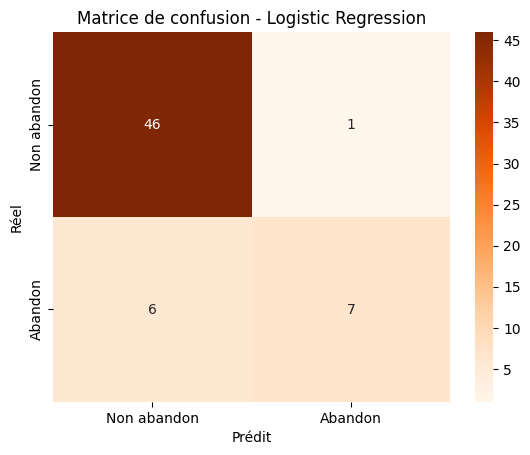


Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.98      0.93        47
           1       0.88      0.54      0.67        13

    accuracy                           0.88        60
   macro avg       0.88      0.76      0.80        60
weighted avg       0.88      0.88      0.87        60



In [37]:
# dans cette partie , on lance le modele de regression logistique avec les meilleurs parametres du gread search 
best_model = LogisticRegression(**grid.best_params_)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test) 


print("=== regression logistique===")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Oranges",
            xticklabels=["Non abandon", "Abandon"],
            yticklabels=["Non abandon", "Abandon"])

plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion - Logistic Regression")
plt.show()
print("\nClassification Report:\n", classification_report(y_test, y_pred))

=== Random Forest ===
Accuracy : 0.9666666666666667
Precision : 1.0
Recall : 0.8461538461538461
F1-score : 0.9166666666666666


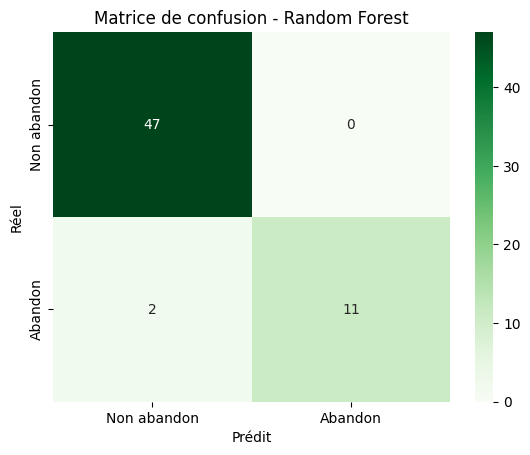


Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98        47
           1       1.00      0.85      0.92        13

    accuracy                           0.97        60
   macro avg       0.98      0.92      0.95        60
weighted avg       0.97      0.97      0.97        60



In [38]:
# On entraîne le modèle avec les meilleurs paramètres trouvés
best_model_rf= RandomForestClassifier(**grid_rf.best_params_)
best_model_rf.fit(X_train, y_train)

# Prédictions
y_pred_rf = best_model_rf.predict(X_test)

# Évaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("=== Random Forest ===")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision :", precision_score(y_test, y_pred_rf))
print("Recall :", recall_score(y_test, y_pred_rf))
print("F1-score :", f1_score(y_test, y_pred_rf))
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure()
sns.heatmap(cm_rf,
            annot=True,
            fmt="d",
            cmap="Greens",
            xticklabels=["Non abandon", "Abandon"],
            yticklabels=["Non abandon", "Abandon"])

plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion - Random Forest")
plt.show()
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

=== SVM ===
Accuracy : 0.9
Precision : 0.8888888888888888
Recall : 0.6153846153846154
F1-score : 0.7272727272727273


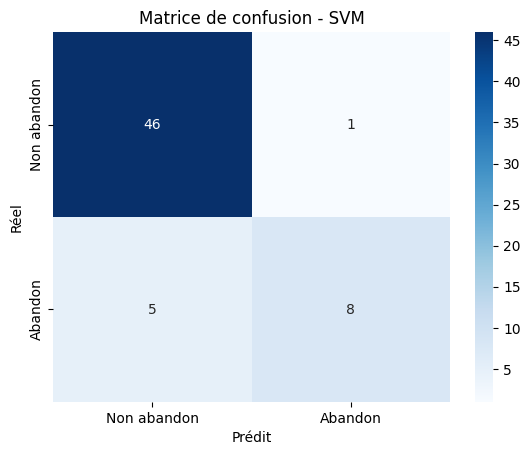


Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.98      0.94        47
           1       0.89      0.62      0.73        13

    accuracy                           0.90        60
   macro avg       0.90      0.80      0.83        60
weighted avg       0.90      0.90      0.89        60



In [39]:
# On entraîne le modèle avec les meilleurs paramètres trouvés
best_model_svm = SVC(**gride.best_params_)
best_model_svm.fit(X_train, y_train)

# Prédictions
y_pred_svm = best_model_svm.predict(X_test)

# Évaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("=== SVM ===")
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision :", precision_score(y_test, y_pred_svm))
print("Recall :", recall_score(y_test, y_pred_svm))
print("F1-score :", f1_score(y_test, y_pred_svm))

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure()
sns.heatmap(cm, 
            annot=True, 
            fmt="d", 
            cmap="Blues",
            xticklabels=["Non abandon", "Abandon"],
            yticklabels=["Non abandon", "Abandon"])

plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion - SVM")
plt.show()
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

In [40]:
joblib.dump(X_train.columns.tolist(), "features.pkl")

['features.pkl']

In [41]:
import joblib

features = joblib.load("features.pkl")
print(features)

['average_grade', 'absenteeism_rate', 'study_time_hours', 'study_absence_ratio', 'score_global']


In [42]:

joblib.dump(best_model_rf, "model_dropout.pkl")

['model_dropout.pkl']